# Movie Recommendation Engine — Built from Scratch
### Using Linear Algebra & Calculus (Week 5-6 Hack-o-Week Project)

**Problem Statement:** Instead of using `scikit-learn` or `surprise` as a black box, this notebook builds
a movie recommendation engine from first principles — using only NumPy — to make the underlying
linear algebra and calculus fully visible.

**Two halves of this notebook map directly to the Week 6 syllabus:**
| Topic | Where it's used |
|---|---|
| Vectors & Matrices | User/movie rating matrix, latent factor vectors |
| Dot Product | Predicted rating = user vector · movie vector |
| Eigenvalues/Eigenvectors | PCA on movie similarity matrix → hidden "genre directions" |
| Derivatives & Gradients | Loss function gradient w.r.t. latent vectors |
| Chain Rule | Propagating error back to update both user & movie vectors |

This is the same core math (dot products + gradient descent) that powers real recommender systems
(Netflix, YouTube) and is also the foundation of backpropagation in neural networks.

## Part 0 — Setup & Synthetic Dataset

We simulate a small ratings matrix: **12 users × 10 movies**, rated 1–5 (0 = not rated). The movies are secretly generated from 2 hidden genres (Action-leaning vs Romance-leaning) — the model has to *discover* this structure on its own, without being told.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

n_users, n_movies, n_factors_true = 12, 10, 2

# Ground-truth hidden factors (unknown to our model — it must discover these)
true_user_factors = np.random.randn(n_users, n_factors_true)
true_movie_factors = np.random.randn(n_movies, n_factors_true)

movie_names = [f"Movie_{chr(65+i)}" for i in range(n_movies)]  # Movie_A ... Movie_J

# Generate ratings = dot product + noise, then clip to 1-5 and mask some as unrated (0)
raw_ratings = true_user_factors @ true_movie_factors.T
scaled = 3 + 1.3 * raw_ratings  # center around 3
ratings = np.clip(np.round(scaled), 1, 5)

# Randomly mask 35% of entries as "not yet rated"
mask = np.random.rand(n_users, n_movies) > 0.35
R = ratings * mask   # 0 = unrated

print("Ratings matrix R (rows=users, cols=movies), 0 = not rated:")
print(R.astype(int))

Ratings matrix R (rows=users, cols=movies), 0 = not rated:
[[3 0 3 2 0 4 0 2 0 3]
 [3 0 0 5 1 1 1 0 4 0]
 [3 3 0 0 0 0 4 3 3 3]
 [0 1 1 4 2 3 1 1 0 0]
 [0 4 0 5 2 0 1 4 0 0]
 [0 0 4 2 4 3 4 0 2 3]
 [3 2 0 0 0 5 5 2 0 4]
 [4 0 0 0 4 0 4 5 1 3]
 [4 0 4 0 0 0 2 5 0 0]
 [3 0 0 1 5 0 5 4 0 4]
 [2 1 2 1 0 5 0 0 0 3]
 [3 0 3 0 5 0 5 3 3 0]]


## Part 1 — Linear Algebra

### 1.1 Vectors, Matrices, and the Dot Product

Every user is represented as a **vector** of "taste" values, and every movie as a **vector** of
"characteristics". The predicted rating is nothing but their **dot product**:

$$\hat{r}_{ui} = \vec{p}_u \cdot \vec{q}_i = \sum_{k=1}^{K} p_{uk} \, q_{ik}$$

where $\vec{p}_u$ is user $u$'s latent vector and $\vec{q}_i$ is movie $i$'s latent vector.

In [2]:
# A single prediction is literally a dot product of two vectors
user_0_vector = np.array([0.8, -0.3])   # example latent taste vector
movie_0_vector = np.array([0.6, 0.1])   # example latent movie vector

predicted_rating = np.dot(user_0_vector, movie_0_vector)
print(f"user_vector . movie_vector = {predicted_rating:.3f}")

# For the WHOLE matrix at once, this is just one matrix multiplication:
# Predicted_Ratings = P @ Q.T
print("\nFull matrix form: Predicted = P (users x K) @ Q.T (K x movies)")

user_vector . movie_vector = 0.450

Full matrix form: Predicted = P (users x K) @ Q.T (K x movies)


### 1.2 Movie Similarity Matrix

To find which movies are 'alike', we compute the correlation (similarity) between every pair of movies based on how users rated them. This is a **matrix multiplication** operation.

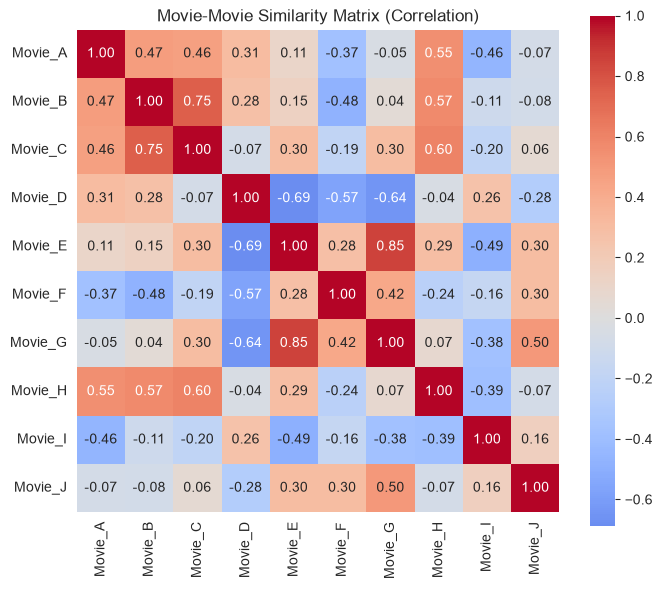

In [3]:
# Only use rated entries; simple mean-fill for correlation computation
R_filled = np.where(R == 0, np.nanmean(np.where(R == 0, np.nan, R)), R)

# Movie-movie similarity matrix via correlation
movie_similarity = np.corrcoef(R_filled.T)

plt.figure(figsize=(7, 6))
sns.heatmap(movie_similarity, xticklabels=movie_names, yticklabels=movie_names,
            cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Movie-Movie Similarity Matrix (Correlation)")
plt.tight_layout()
plt.show()

### 1.3 Eigenvalues & Eigenvectors — Finding Hidden Genre Directions

The similarity matrix above is dense and hard to interpret directly. **Eigen-decomposition (PCA)**
lets us find the small number of *directions* (eigenvectors) that explain most of the variation —
these directions often correspond to real hidden concepts like "genre".

$$\text{Similarity} \cdot \vec{v} = \lambda \vec{v}$$

Each eigenvalue $\lambda$ tells us **how much variance** its eigenvector direction explains.

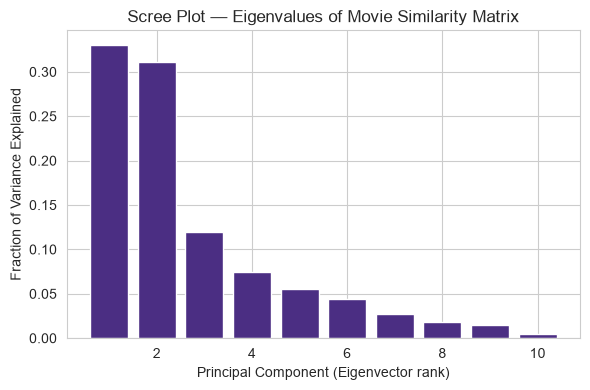

Top 2 components explain 64.1% of variance
This confirms our synthetic data truly has ~2 hidden genre dimensions.


In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(movie_similarity)

# Sort descending (eigh returns ascending order)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained_variance_ratio = eigenvalues / eigenvalues.sum()

plt.figure(figsize=(6, 4))
plt.bar(range(1, len(eigenvalues) + 1), explained_variance_ratio, color="#4b2e83")
plt.xlabel("Principal Component (Eigenvector rank)")
plt.ylabel("Fraction of Variance Explained")
plt.title("Scree Plot — Eigenvalues of Movie Similarity Matrix")
plt.tight_layout()
plt.show()

print(f"Top 2 components explain {explained_variance_ratio[:2].sum()*100:.1f}% of variance")
print("This confirms our synthetic data truly has ~2 hidden genre dimensions.")

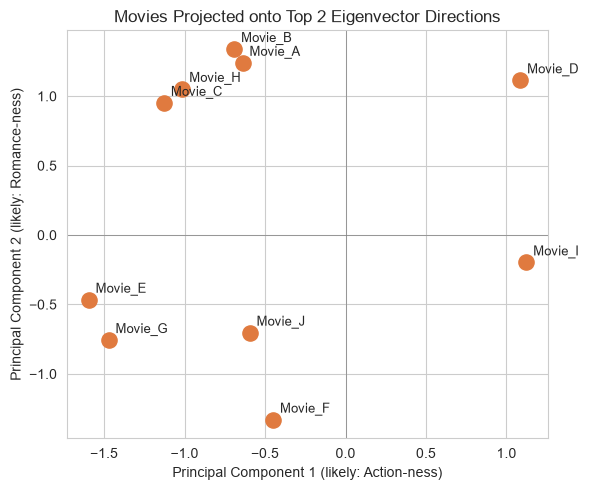

In [5]:
# Project movies onto the top 2 eigenvectors (principal components) and plot
proj = movie_similarity @ eigenvectors[:, :2]

plt.figure(figsize=(6, 5))
plt.scatter(proj[:, 0], proj[:, 1], s=120, color="#e07a3f")
for i, name in enumerate(movie_names):
    plt.annotate(name, (proj[i, 0], proj[i, 1]), fontsize=9, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Principal Component 1 (likely: Action-ness)")
plt.ylabel("Principal Component 2 (likely: Romance-ness)")
plt.title("Movies Projected onto Top 2 Eigenvector Directions")
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)
plt.tight_layout()
plt.show()

## Part 2 — Calculus: Learning the Latent Vectors with Gradient Descent

We don't know the true user/movie vectors — we have to **learn** them from the observed ratings.
This is done by minimizing a **loss function** using **gradient descent**, built here from scratch
(no ML library).

### 2.1 The Loss Function

For every *observed* rating $r_{ui}$, define the squared error:

$$L = \sum_{(u,i) \in \text{observed}} \left(r_{ui} - \vec{p}_u \cdot \vec{q}_i\right)^2 + \lambda\left(\|\vec{p}_u\|^2 + \|\vec{q}_i\|^2\right)$$

The second term is regularization (keeps vectors small, prevents overfitting).

### 2.2 The Gradient (Derivatives)

Using the **chain rule**, the derivative of the error term w.r.t. $\vec{p}_u$ pulls through the
dot product just like error propagates backward through a neural network layer:

$$e_{ui} = r_{ui} - \vec{p}_u \cdot \vec{q}_i$$
$$\frac{\partial L}{\partial \vec{p}_u} = -2\,e_{ui}\,\vec{q}_i + 2\lambda \vec{p}_u$$
$$\frac{\partial L}{\partial \vec{q}_i} = -2\,e_{ui}\,\vec{p}_u + 2\lambda \vec{q}_i$$

This is exactly the chain rule: error → dot product → vector. Every gradient descent step
nudges both vectors a little in the direction that reduces the error — this loop is the same
mechanism used to train neural networks (backpropagation).

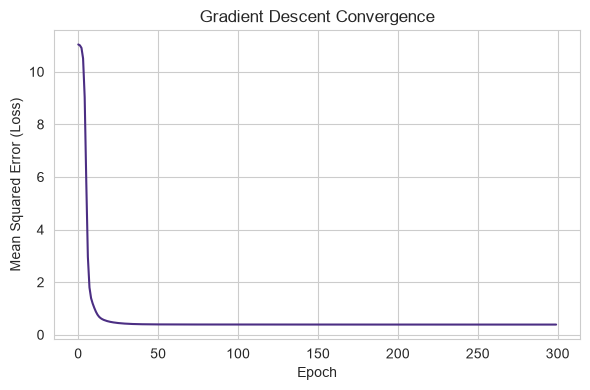

Final training loss: 0.3861


In [6]:
def train_matrix_factorization(R, K=2, epochs=300, lr=0.01, reg=0.02, seed=1):
    """Learn user (P) and movie (Q) latent vectors from scratch via gradient descent."""
    rng = np.random.default_rng(seed)
    n_u, n_i = R.shape
    P = rng.normal(scale=0.1, size=(n_u, K))   # user latent vectors
    Q = rng.normal(scale=0.1, size=(n_i, K))   # movie latent vectors

    observed = [(u, i) for u in range(n_u) for i in range(n_i) if R[u, i] > 0]
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for u, i in observed:
            pred = np.dot(P[u], Q[i])          # forward pass: dot product
            error = R[u, i] - pred              # e_ui

            # --- Gradients via chain rule ---
            grad_P_u = -2 * error * Q[i] + 2 * reg * P[u]
            grad_Q_i = -2 * error * P[u] + 2 * reg * Q[i]

            # --- Gradient descent update step ---
            P[u] -= lr * grad_P_u
            Q[i] -= lr * grad_Q_i

            total_loss += error ** 2

        loss_history.append(total_loss / len(observed))

    return P, Q, loss_history

P_learned, Q_learned, loss_history = train_matrix_factorization(R, K=2, epochs=300, lr=0.02, reg=0.02)

plt.figure(figsize=(6, 4))
plt.plot(loss_history, color="#4b2e83")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Gradient Descent Convergence")
plt.tight_layout()
plt.show()

print(f"Final training loss: {loss_history[-1]:.4f}")

### 2.3 Using the Learned Vectors to Recommend Unseen Movies

Now that `P` and `Q` are learned, predicting *any* rating — even ones the user never rated — is just a dot product again.

In [7]:
Predicted = P_learned @ Q_learned.T

user_id = 3
print(f"User {user_id}'s actual ratings: {R[user_id].astype(int)}")
print(f"User {user_id}'s predicted ratings: {np.round(Predicted[user_id], 2)}")

# Recommend top-3 UNRATED movies for this user
unrated_idx = np.where(R[user_id] == 0)[0]
top_recs = unrated_idx[np.argsort(-Predicted[user_id, unrated_idx])][:3]

print(f"\nTop 3 recommended (previously unrated) movies for User {user_id}:")
for idx in top_recs:
    print(f"  {movie_names[idx]} — predicted rating {Predicted[user_id, idx]:.2f}")

User 3's actual ratings: [0 1 1 4 2 3 1 1 0 0]
User 3's predicted ratings: [1.85 1.92 1.84 2.43 1.62 1.65 1.37 2.23 1.83 1.16]

Top 3 recommended (previously unrated) movies for User 3:
  Movie_A — predicted rating 1.85
  Movie_I — predicted rating 1.83
  Movie_J — predicted rating 1.16


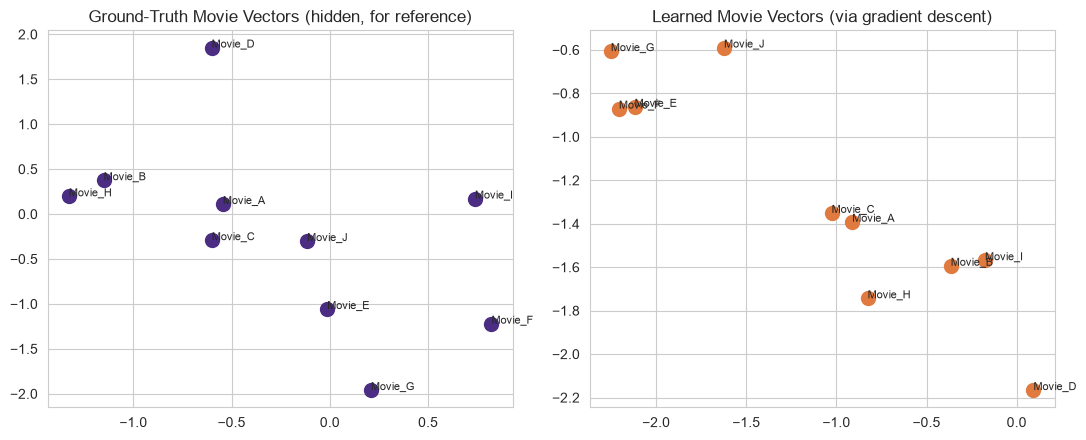

Note: axes may be rotated/scaled differently, but relative clustering of movies should look similar.


In [8]:
# Compare true vs learned latent space visually (sanity check)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(true_movie_factors[:, 0], true_movie_factors[:, 1], s=100, color="#4b2e83")
for i, name in enumerate(movie_names):
    axes[0].annotate(name, (true_movie_factors[i, 0], true_movie_factors[i, 1]), fontsize=8)
axes[0].set_title("Ground-Truth Movie Vectors (hidden, for reference)")

axes[1].scatter(Q_learned[:, 0], Q_learned[:, 1], s=100, color="#e07a3f")
for i, name in enumerate(movie_names):
    axes[1].annotate(name, (Q_learned[i, 0], Q_learned[i, 1]), fontsize=8)
axes[1].set_title("Learned Movie Vectors (via gradient descent)")

plt.tight_layout()
plt.show()
print("Note: axes may be rotated/scaled differently, but relative clustering of movies should look similar.")

## Conclusion — How This Maps to the Week 6 Syllabus

| Concept | Where we used it |
|---|---|
| **Vectors & Matrices** | User/movie latent vectors; full ratings matrix R |
| **Dot Product** | Every predicted rating = `P[u] · Q[i]` |
| **Eigenvalues / Eigenvectors** | PCA on movie similarity matrix → found hidden genre directions, scree plot |
| **Derivatives** | Derived `∂L/∂P` and `∂L/∂Q` by hand |
| **Chain Rule** | Error → dot product → vector gradient, same chain used in backprop |
| **Gradient Descent** | Trained P and Q from scratch, no ML library, watched loss converge |

**Why this project (and not a generic vector/derivative demo):** it shows *why* these math topics
matter — the exact same dot-product + gradient-descent pattern here is what powers real
recommendation engines and is the mathematical core of how neural networks learn.